# Chapter 13: The Gauss-Bonnet Theorem

**Source span.** Pressley, *Elementary Differential Geometry*, Chapter 13, printed pp. 335-378, PDF pp. 336-378, Sections 13.1-13.8.

**Chapter question.** How can a local measurement of turning and Gaussian curvature force a global topological number?

A single invariant keeps reappearing. A boundary term, an area curvature term, and a small amount of topology must balance. Locally this is a statement about one curve. Globally it becomes \(\int_S K\,dA = 2\pi\chi(S)\). In applications it reappears as a coloring bound, as holonomy, as the sum of vector-field indices, and as a Morse count for critical points.


## Computational Translation Guide

| Pressley object | Computational representation in this notebook | What to inspect |
| --- | --- | --- |
| Simple closed curve on a patch | Sampled boundary plus curvature-area budget | Boundary turning and enclosed total curvature add to \(2\pi\). |
| Curvilinear polygon | Great-circle triangle on \(S^2\) | Angle excess equals spherical area when the edges are geodesics. |
| Integration on compact surfaces | Tubular shell limit around a unit sphere | Normal thickening recovers the surface integral as thickness shrinks. |
| Triangulated compact surface | Small mesh and proof ledger | Vertex, edge, face, and edge-cancellation terms leave \(2\pi\chi\). |
| Map coloring | Dual adjacency graph and Heawood bound table | Euler characteristic limits how many mutually adjacent countries can be forced. |
| Holonomy | Spherical cap area and transported-angle budget | Curvature enclosed by a loop equals the angle gained by parallel transport. |
| Vector-field singularity | Winding number of a tangent vector along a small circle | Source, sink, vortex, and saddle contribute indices \(+1,+1,+1,-1\). |
| Critical point | Torus distance function and Hessian signs | Maxima and minima contribute \(+1\); saddles contribute \(-1\). |


## Route Through The Chapter

1. Convert local Gauss-Bonnet into a visible budget: boundary geodesic curvature plus enclosed curvature.
2. Add vertices and see the angle correction for curvilinear polygons.
3. Replace one patch by a compact surface using a normal-thickening model for integration.
4. Sum polygon formulas over a triangulation and watch all interior edge terms cancel.
5. Use Euler characteristic to constrain map coloring.
6. Read holonomy as curvature detected by parallel transport around a loop.
7. Count stationary points of vector fields by local winding number.
8. Apply that index count to gradients of functions and recover the Morse count.

The main visuals are split into curvature, topology, and proof-state views. The curvature views show measured quantities, the topology views show integer ledgers, and the proof-state views show which terms cancel or survive.


In [1]:
from pathlib import Path
import sys

START = Path.cwd().resolve()
BOOK_ROOT = None
for candidate in [START, *START.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").is_dir():
        BOOK_ROOT = candidate
        break

if BOOK_ROOT is None:
    for root in [START, *START.parents]:
        possible = root / "Elementary-Differential-Geometry-Andrew-Pressley"
        if (possible / "00-book-index.ipynb").exists() and (possible / "utils").is_dir():
            BOOK_ROOT = possible
            break

if BOOK_ROOT is None:
    raise RuntimeError("Could not locate the Pressley book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, save_json  # noqa: E402

UNIT = "chapter-13"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts"
CHAPTER_ARTIFACTS = ARTIFACT_ROOT / UNIT
FIGURES = CHAPTER_ARTIFACTS / "figures"
INTERACTIVE = CHAPTER_ARTIFACTS / "interactive"
CHECKS = CHAPTER_ARTIFACTS / "checks"
TABLES = CHAPTER_ARTIFACTS / "tables"
for folder in [FIGURES, INTERACTIVE, CHECKS, TABLES]:
    folder.mkdir(parents=True, exist_ok=True)

def rel(path):
    return Path(path).resolve().relative_to(BOOK_ROOT).as_posix()

print(f"Book root: {BOOK_ROOT}")
print(f"Chapter artifacts: {CHAPTER_ARTIFACTS}")


Book root: D:\Geometry\Elementary-Differential-Geometry-Andrew-Pressley
Chapter artifacts: D:\Geometry\Elementary-Differential-Geometry-Andrew-Pressley\artifacts\chapter-13


In [2]:
import math

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
import trimesh

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 180,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

TAU = 2 * math.pi
TOL = 1e-9


## Source Map And Visual Storyboard

The source span was used for structure and terminology only. The notebook prose, computations, diagrams, and examples below are original. Each storyboard item has an inspection target and a check so the visuals do not become decoration.


In [3]:
source_span = {
    "book": "Andrew Pressley, Elementary Differential Geometry, Second Edition",
    "chapter": "Chapter 13: The Gauss-Bonnet theorem",
    "printed_pages": "335-378",
    "pdf_pages": "336-378",
    "sections": ["13.1", "13.2", "13.3", "13.4", "13.5", "13.6", "13.7", "13.8"],
    "source_use": "orientation only; no textbook prose, figures, hints, solutions, screenshots, or page crops copied",
}
source_span_path = save_json(source_span, UNIT, "checks", "source-span.json", root=ARTIFACT_ROOT)

visual_storyboard = [
    {"item": "local_gauss_bonnet_budget", "concept": "simple closed curves and total curvature", "representation": "boundary/area curvature budget for spherical caps", "library": "Matplotlib", "artifact": "figures/local-gauss-bonnet-budget.png", "inspection_target": "the terms change with cap size but their sum stays 2*pi", "validation": "boundary_integral + area_integral = 2*pi"},
    {"item": "curvilinear_polygon", "concept": "geodesic polygon angle excess", "representation": "rotatable octant triangle on the unit sphere", "library": "Plotly", "artifact": "interactive/spherical-triangle-angle-area.html", "inspection_target": "three right angles enclose area pi/2", "validation": "angle_sum - pi = area"},
    {"item": "compact_surface_integration", "concept": "normal thickening definition of surface integral", "representation": "tube-shell limit for the unit sphere", "library": "Matplotlib and SymPy", "artifact": "figures/compact-integration-tube-limit.png", "inspection_target": "normalized shell volume tends to area", "validation": "limit volume(shell)/(2*epsilon) = 4*pi"},
    {"item": "global_proof_state", "concept": "global Gauss-Bonnet from polygon summation", "representation": "proof dependency graph plus mesh Euler ledgers", "library": "NetworkX and Trimesh", "artifact": "figures/proof-state-global-gauss-bonnet.png", "inspection_target": "vertex, edge, face, and cancellation terms leave Euler characteristic", "validation": "mesh V-E+F matches sphere and torus chi"},
    {"item": "map_coloring", "concept": "Euler characteristic as a coloring constraint", "representation": "Heawood table and K7 torus-neighbor graph", "library": "NetworkX and Matplotlib", "artifact": "figures/map-coloring-heawood-bound.png", "inspection_target": "the torus permits a seven-country mutual-neighbor obstruction", "validation": "h(0)=7 and omega(K7)=7"},
    {"item": "holonomy", "concept": "parallel-transport angle equals enclosed curvature", "representation": "spherical cap area versus holonomy curve", "library": "Matplotlib", "artifact": "figures/holonomy-curvature-area.png", "inspection_target": "holonomy grows exactly with cap area", "validation": "holonomy - integral_K_dA = 0"},
    {"item": "vector_field_indices", "concept": "multiplicity of stationary vector-field points", "representation": "streamplot gallery and winding-number computation", "library": "Matplotlib", "artifact": "figures/vector-field-index-gallery.png", "inspection_target": "a saddle reverses winding", "validation": "numeric winding indices [1, 1, 1, -1]"},
    {"item": "critical_points", "concept": "gradient index and Morse count", "representation": "rotatable torus colored by a distance function with critical markers", "library": "Plotly and SymPy", "artifact": "interactive/torus-critical-points.html", "inspection_target": "two saddles cancel one max and one min on a torus", "validation": "maxima - saddles + minima = 0 = chi(T1)"},
]
storyboard_path = save_json(visual_storyboard, UNIT, "checks", "visual-storyboard.json", root=ARTIFACT_ROOT)
pd.DataFrame(visual_storyboard)[["item", "concept", "library", "artifact", "validation"]]


,item,concept,library,artifact,validation
0,local_gauss_bonnet_budget,simple closed curves and total curvature,Matplotlib,figures/local-gauss-bonnet-budget.png,boundary_integral + area_integral = 2*pi
1,curvilinear_polygon,geodesic polygon angle excess,Plotly,interactive/spherical-triangle-angle-area.html,angle_sum - pi = area
2,compact_surface_integration,normal thickening definition of surface integral,Matplotlib and SymPy,figures/compact-integration-tube-limit.png,limit volume(shell)/(2*epsilon) = 4*pi
3,global_proof_state,global Gauss-Bonnet from polygon summation,NetworkX and Trimesh,figures/proof-state-global-gauss-bonnet.png,mesh V-E+F matches sphere and torus chi
4,map_coloring,Euler characteristic as a coloring constraint,NetworkX and Matplotlib,figures/map-coloring-heawood-bound.png,h(0)=7 and omega(K7)=7
5,holonomy,parallel-transport angle equals enclosed curva...,Matplotlib,figures/holonomy-curvature-area.png,holonomy - integral_K_dA = 0
6,vector_field_indices,multiplicity of stationary vector-field points,Matplotlib,figures/vector-field-index-gallery.png,"numeric winding indices [1, 1, 1, -1]"
7,critical_points,gradient index and Morse count,Plotly and SymPy,interactive/torus-critical-points.html,maxima - saddles + minima = 0 = chi(T1)


## Local Gauss-Bonnet: A Curvature Budget

For a positively oriented simple closed curve on a patch, the formula can be read as a budget:

\[
\int_{\partial R} \kappa_g\,ds + \int_R K\,dA = 2\pi.
\]

On the unit sphere, a cap of geodesic radius \(\rho\) has area \(2\pi(1-\cos\rho)\), while its boundary contributes \(2\pi\cos\rho\). The two terms trade size as the cap grows, but the budget remains fixed.


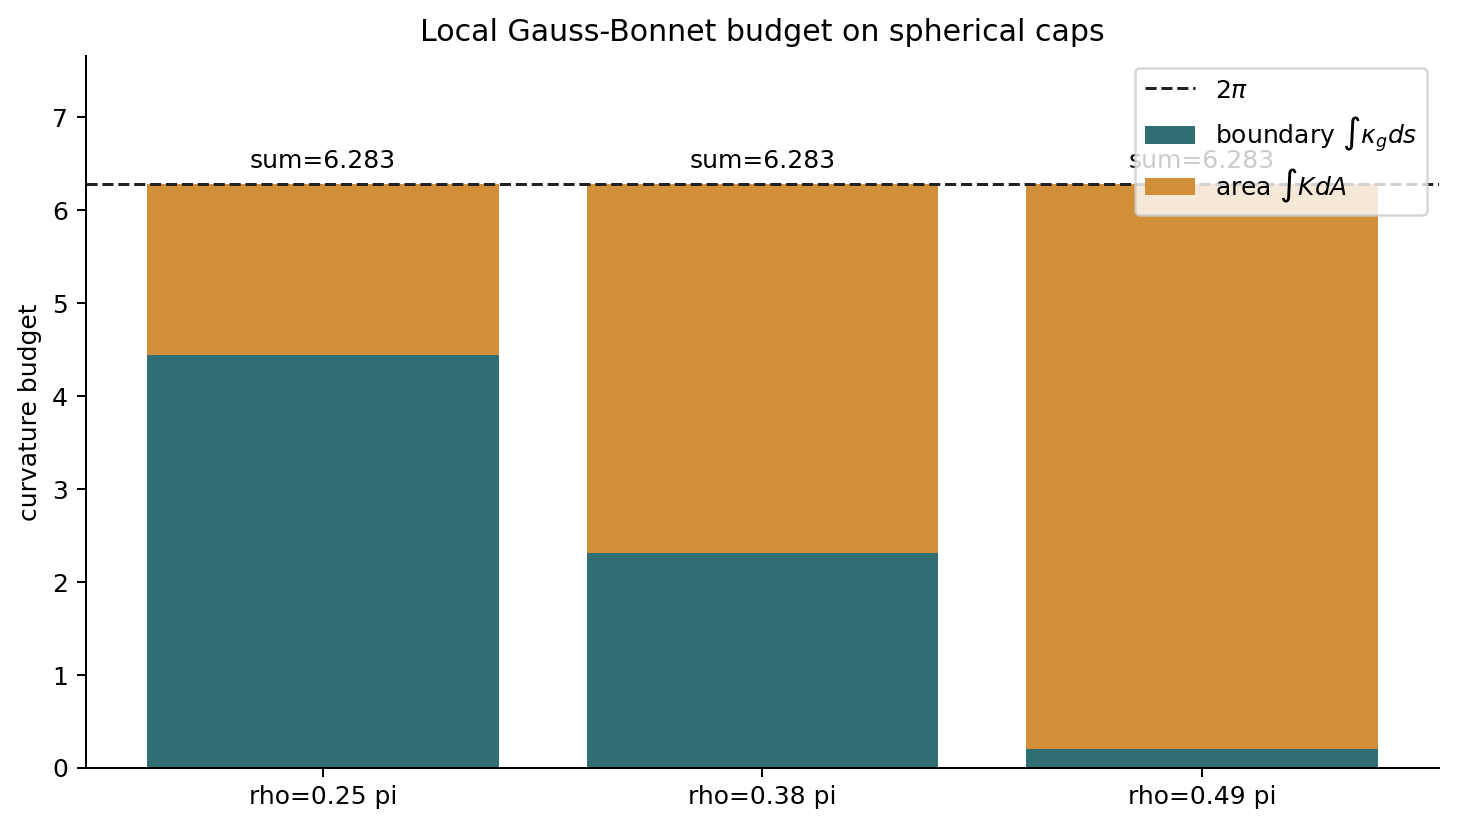

,rho,boundary_geodesic_curvature,enclosed_total_curvature,boundary_plus_area,target,residual
0,0.785398,4.442883,1.840302,6.283185,6.283185,0.0
1,1.193805,2.312995,3.970191,6.283185,6.283185,0.0
2,1.539380,0.197360,6.085826,6.283185,6.283185,0.0


In [4]:
rhos = np.array([0.25 * math.pi, 0.38 * math.pi, 0.49 * math.pi])
local_rows = []
for rho_value in rhos:
    boundary = TAU * math.cos(rho_value)
    area = TAU * (1.0 - math.cos(rho_value))
    local_rows.append({
        "rho": float(rho_value),
        "boundary_geodesic_curvature": float(boundary),
        "enclosed_total_curvature": float(area),
        "boundary_plus_area": float(boundary + area),
        "target": float(TAU),
        "residual": float(boundary + area - TAU),
    })

local_df = pd.DataFrame(local_rows)
local_budget_path = FIGURES / "local-gauss-bonnet-budget.png"
fig, ax = plt.subplots(figsize=(8.2, 4.7))
x = np.arange(len(local_df))
ax.bar(x, local_df["boundary_geodesic_curvature"], label=r"boundary $\int \kappa_g ds$", color="#2f6f73")
ax.bar(x, local_df["enclosed_total_curvature"], bottom=local_df["boundary_geodesic_curvature"], label=r"area $\int K dA$", color="#d18f39")
ax.axhline(TAU, color="#222222", linewidth=1.2, linestyle="--", label=r"$2\pi$")
ax.set_xticks(x, [f"rho={rho_value/math.pi:.2f} pi" for rho_value in rhos])
ax.set_ylabel("curvature budget")
ax.set_title("Local Gauss-Bonnet budget on spherical caps")
ax.legend(loc="upper right")
ax.set_ylim(0, TAU * 1.22)
for i, total in enumerate(local_df["boundary_plus_area"]):
    ax.text(i, total + 0.12, f"sum={total:.3f}", ha="center", va="bottom")
fig.tight_layout()
fig.savefig(local_budget_path, bbox_inches="tight")
plt.close(fig)

local_budget_check = {
    "identity": "int_boundary_kappa_g_ds + int_region_K_dA = 2*pi for unit-sphere caps",
    "rows": local_rows,
    "max_abs_residual": float(np.max(np.abs(local_df["residual"]))),
}
local_budget_check_path = save_json(local_budget_check, UNIT, "checks", "local-gauss-bonnet-budget.json", root=ARTIFACT_ROOT)

assert local_budget_check["max_abs_residual"] < TOL
assert_artifact(local_budget_path, min_bytes=1000)
display_artifact(local_budget_path, width=900)
local_df


## Curvilinear Polygons: Vertices Add Angle Terms

A smooth boundary has only a curvature integral. A polygonal boundary also has jumps in tangent direction. For a geodesic \(n\)-gon, the edge curvature terms vanish and the angle sum detects total curvature:

\[
\sum_i \alpha_i - (n-2)\pi = \int_R K\,dA.
\]

The spherical octant triangle has three great-circle edges and three right angles. Its excess is \(3\pi/2-\pi=\pi/2\), matching its area on the unit sphere.


In [5]:
# Unit-sphere octant triangle: A=(1,0,0), B=(0,1,0), C=(0,0,1).
theta = np.linspace(0, math.pi / 2, 64)
phi = np.linspace(0, math.pi / 2, 64)
Theta, Phi = np.meshgrid(theta, phi)
X = np.sin(Theta) * np.cos(Phi)
Y = np.sin(Theta) * np.sin(Phi)
Z = np.cos(Theta)

fig = go.Figure()
fig.add_surface(x=X, y=Y, z=Z, opacity=0.48, colorscale=[[0, "#dce8f2"], [1, "#8fb3cf"]], showscale=False, name="spherical octant")
arc_t = np.linspace(0, math.pi / 2, 100)
arcs = {
    "AB": (np.cos(arc_t), np.sin(arc_t), np.zeros_like(arc_t)),
    "BC": (np.zeros_like(arc_t), np.cos(arc_t), np.sin(arc_t)),
    "CA": (np.sin(arc_t), np.zeros_like(arc_t), np.cos(arc_t)),
}
for name, (xx, yy, zz) in arcs.items():
    fig.add_trace(go.Scatter3d(x=xx, y=yy, z=zz, mode="lines", line=dict(color="#0f4c5c", width=7), name=f"great-circle edge {name}"))
vertices = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
fig.add_trace(go.Scatter3d(
    x=vertices[:, 0], y=vertices[:, 1], z=vertices[:, 2],
    mode="markers+text", marker=dict(size=6, color="#b53d2d"),
    text=["A", "B", "C"], textposition="top center", name="vertices"
))
fig.update_layout(
    title="Geodesic triangle on the unit sphere: angle excess equals area",
    scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="z"),
    margin=dict(l=0, r=0, t=48, b=0),
    height=560,
)
triangle_html = INTERACTIVE / "spherical-triangle-angle-area.html"
fig.write_html(triangle_html, include_plotlyjs=True, full_html=True)

triangle_check = {
    "surface": "unit sphere",
    "polygon": "octant geodesic triangle",
    "n_edges": 3,
    "interior_angles": [float(math.pi / 2)] * 3,
    "angle_sum": float(3 * math.pi / 2),
    "plane_triangle_sum": float(math.pi),
    "angle_excess": float(math.pi / 2),
    "area_integral_K_dA": float(math.pi / 2),
    "residual": 0.0,
}
triangle_check_path = save_json(triangle_check, UNIT, "checks", "spherical-triangle-angle-area.json", root=ARTIFACT_ROOT)

assert abs(triangle_check["angle_excess"] - triangle_check["area_integral_K_dA"]) < TOL
assert_artifact(triangle_html, min_bytes=1000)
display_artifact(triangle_html, width="100%", height=590)
triangle_check


{'surface': 'unit sphere',
 'polygon': 'octant geodesic triangle',
 'n_edges': 3,
 'interior_angles': [1.5707963267948966,
  1.5707963267948966,
  1.5707963267948966],
 'angle_sum': 4.71238898038469,
 'plane_triangle_sum': 3.141592653589793,
 'angle_excess': 1.5707963267948966,
 'area_integral_K_dA': 1.5707963267948966,
 'residual': 0.0}

## Integration On Compact Surfaces: The Tube Limit

For a compact surface, one can define \(\int_S f\,dA\) by extending \(f\) normally to a thin shell around \(S\), taking a volume integral, and dividing by shell thickness. The unit sphere with \(f=1\) is a transparent test case.

The shell between radii \(1-\epsilon\) and \(1+\epsilon\) has volume

\[
\frac{4\pi}{3}\left((1+\epsilon)^3-(1-\epsilon)^3\right).
\]

After division by \(2\epsilon\), this tends to \(4\pi\), the surface area of the unit sphere.


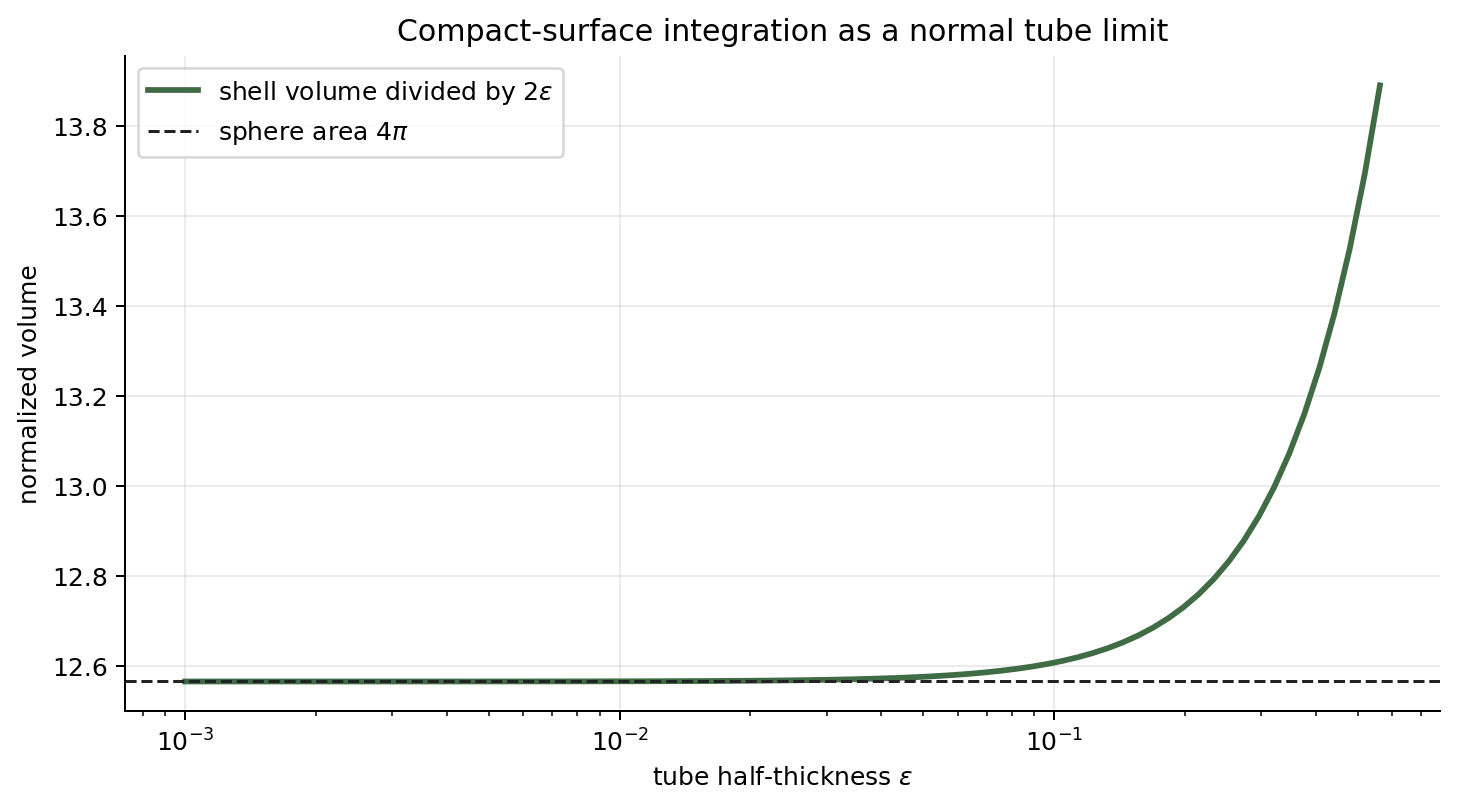

{'identity': 'lim_{epsilon->0} volume(shell)/(2*epsilon) = area(S^2)',
 'symbolic_expression': '4*pi*(epsilon**2 + 3)/3',
 'symbolic_limit': '4*pi',
 'area_sphere': 12.566370614359172,
 'smallest_epsilon': 0.001,
 'relative_error_at_smallest_epsilon': 3.333332876387374e-07}

In [6]:
eps_symbol = sp.symbols("epsilon", positive=True)
shell_expression = sp.Rational(4, 3) * sp.pi * ((1 + eps_symbol) ** 3 - (1 - eps_symbol) ** 3) / (2 * eps_symbol)
shell_limit = sp.limit(shell_expression, eps_symbol, 0, dir="+")
assert sp.simplify(shell_limit - 4 * sp.pi) == 0

eps_values = np.logspace(-3, -0.25, 80)
normalized_shell_area = (4 * math.pi / 3) * ((1 + eps_values) ** 3 - (1 - eps_values) ** 3) / (2 * eps_values)
relative_error = normalized_shell_area / (4 * math.pi) - 1.0

compact_integration_path = FIGURES / "compact-integration-tube-limit.png"
fig, ax = plt.subplots(figsize=(8.2, 4.6))
ax.semilogx(eps_values, normalized_shell_area, color="#3f6c45", linewidth=2.3, label=r"shell volume divided by $2\epsilon$")
ax.axhline(4 * math.pi, color="#222222", linestyle="--", linewidth=1.2, label=r"sphere area $4\pi$")
ax.set_xlabel(r"tube half-thickness $\epsilon$")
ax.set_ylabel("normalized volume")
ax.set_title("Compact-surface integration as a normal tube limit")
ax.legend(loc="best")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(compact_integration_path, bbox_inches="tight")
plt.close(fig)

compact_integration_check = {
    "identity": "lim_{epsilon->0} volume(shell)/(2*epsilon) = area(S^2)",
    "symbolic_expression": str(sp.simplify(shell_expression)),
    "symbolic_limit": str(shell_limit),
    "area_sphere": float(4 * math.pi),
    "smallest_epsilon": float(eps_values[0]),
    "relative_error_at_smallest_epsilon": float(relative_error[0]),
}
compact_integration_check_path = save_json(compact_integration_check, UNIT, "checks", "compact-integration-tube-limit.json", root=ARTIFACT_ROOT)

assert abs(compact_integration_check["relative_error_at_smallest_epsilon"]) < 1e-6
assert_artifact(compact_integration_path, min_bytes=1000)
display_artifact(compact_integration_path, width=900)
compact_integration_check


## Global Gauss-Bonnet: What Survives The Sum

To pass from one polygon to a compact surface, apply the polygon formula to every face and add. Three bookkeeping facts do the work:

- all angles around a vertex add to \(2\pi\), giving \(2\pi V\),
- each edge is counted twice in \(\sum n_i\), giving \(2\pi E\),
- every internal edge is traversed in opposite directions, so geodesic-curvature edge integrals cancel.

The surviving term is \(2\pi(V-E+F)=2\pi\chi\). The proof graph below is a proof-state visual: each node is a term or cancellation used in the summation.


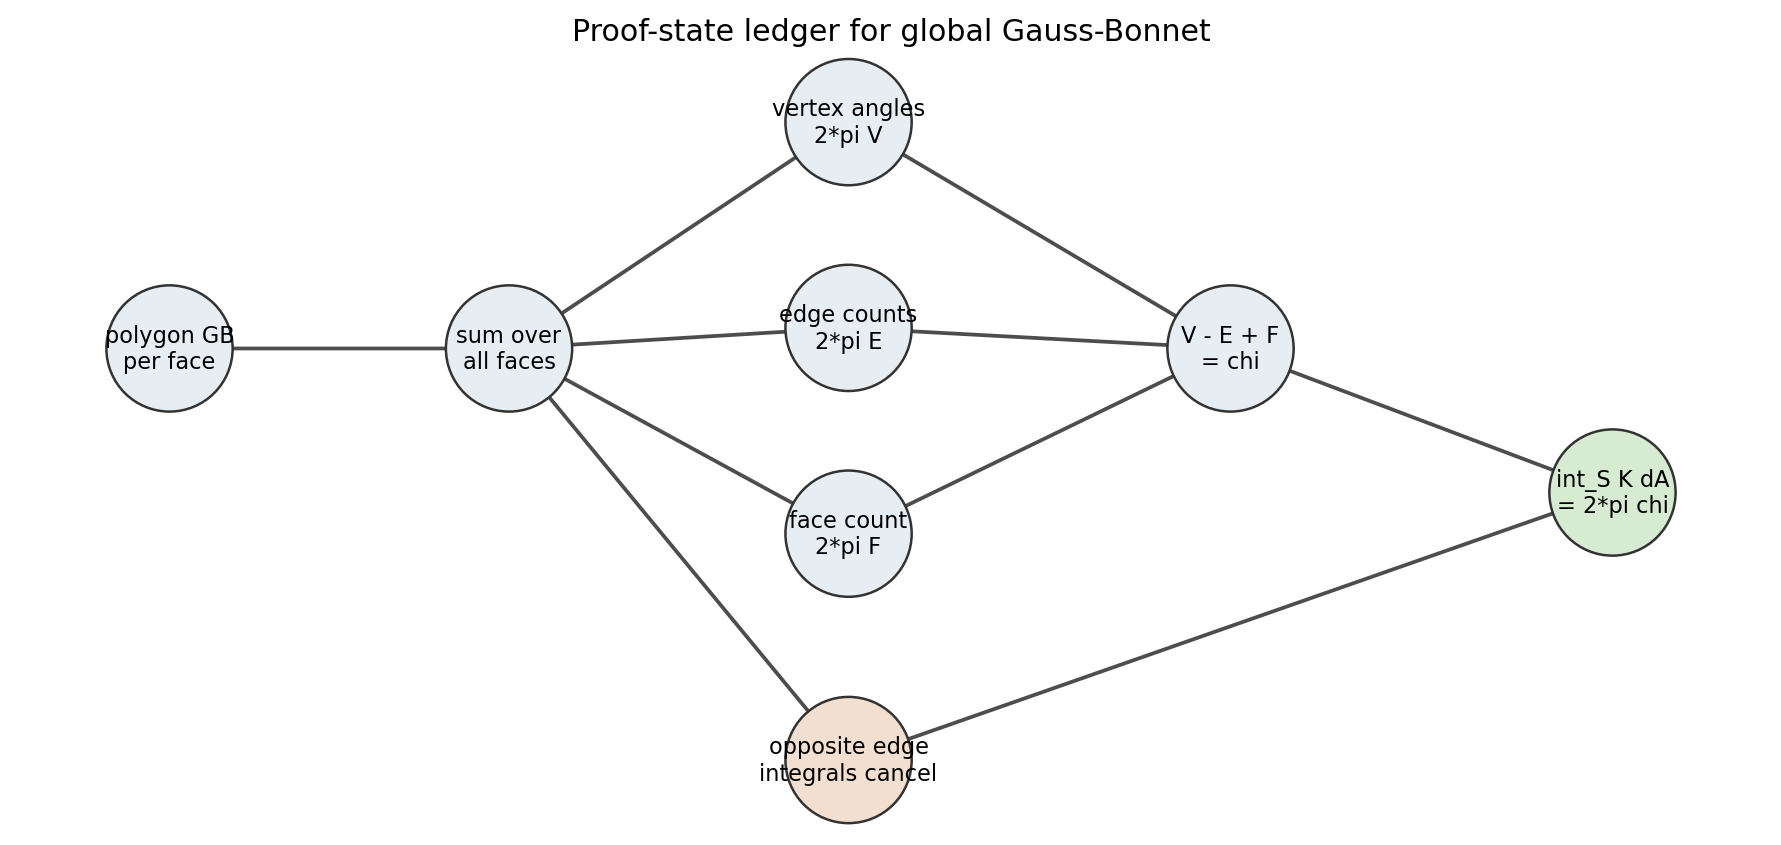

,name,vertices,edges,faces,chi
0,icosphere,162,480,320,2
1,periodic torus mesh,504,1512,1008,0


In [7]:
def torus_mesh(major_radius=2.0, minor_radius=0.65, nu=28, nv=18):
    vertices = []
    faces = []
    for i in range(nu):
        u_angle = TAU * i / nu
        for j in range(nv):
            v_angle = TAU * j / nv
            vertices.append([
                (major_radius + minor_radius * math.cos(v_angle)) * math.cos(u_angle),
                (major_radius + minor_radius * math.cos(v_angle)) * math.sin(u_angle),
                minor_radius * math.sin(v_angle),
            ])
    def idx(i, j):
        return (i % nu) * nv + (j % nv)
    for i in range(nu):
        for j in range(nv):
            faces.append([idx(i, j), idx(i + 1, j), idx(i + 1, j + 1)])
            faces.append([idx(i, j), idx(i + 1, j + 1), idx(i, j + 1)])
    return trimesh.Trimesh(vertices=np.array(vertices), faces=np.array(faces), process=False)

def mesh_ledger(mesh, name):
    V = int(len(mesh.vertices))
    E = int(len(mesh.edges_unique))
    F = int(len(mesh.faces))
    return {"name": name, "vertices": V, "edges": E, "faces": F, "chi": int(V - E + F)}

sphere_mesh = trimesh.creation.icosphere(subdivisions=2, radius=1.0)
torus = torus_mesh()
mesh_ledgers = [mesh_ledger(sphere_mesh, "icosphere"), mesh_ledger(torus, "periodic torus mesh")]

nu_quad = 600
nv_quad = 200
v_mid = (np.arange(nv_quad) + 0.5) * TAU / nv_quad
# For a torus of revolution, K dA = cos(v) du dv.
torus_curvature_integral = float(np.sum(np.cos(v_mid)) * (TAU / nv_quad) * TAU)
global_curvature_checks = {
    "sphere": {"chi": 2, "curvature_integral": float(4 * math.pi), "target": float(2 * math.pi * 2)},
    "torus": {"chi": 0, "curvature_integral_midpoint": torus_curvature_integral, "target": 0.0},
}

G = nx.DiGraph()
node_labels = {
    "polygon": "polygon GB\nper face",
    "sum": "sum over\nall faces",
    "angles": "vertex angles\n2*pi V",
    "edge_count": "edge counts\n2*pi E",
    "faces": "face count\n2*pi F",
    "cancel": "opposite edge\nintegrals cancel",
    "euler": "V - E + F\n= chi",
    "global": "int_S K dA\n= 2*pi chi",
}
G.add_nodes_from(node_labels)
G.add_edges_from([("polygon", "sum"), ("sum", "angles"), ("sum", "edge_count"), ("sum", "faces"), ("sum", "cancel"), ("angles", "euler"), ("edge_count", "euler"), ("faces", "euler"), ("cancel", "global"), ("euler", "global")])
pos = {"polygon": (0.0, 0.9), "sum": (1.2, 0.9), "angles": (2.4, 1.45), "edge_count": (2.4, 0.95), "faces": (2.4, 0.45), "cancel": (2.4, -0.1), "euler": (3.75, 0.9), "global": (5.1, 0.55)}
proof_state_path = FIGURES / "proof-state-global-gauss-bonnet.png"
fig, ax = plt.subplots(figsize=(10, 4.8))
node_colors = ["#e7eef3" if n not in {"cancel", "global"} else ("#f3dfcf" if n == "cancel" else "#d7ead2") for n in G.nodes]
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=15, width=1.5, edge_color="#4d4d4d")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2550, node_color=node_colors, edgecolors="#333333", linewidths=1.0)
nx.draw_networkx_labels(G, pos, labels=node_labels, ax=ax, font_size=9)
ax.set_title("Proof-state ledger for global Gauss-Bonnet")
ax.axis("off")
fig.tight_layout()
fig.savefig(proof_state_path, bbox_inches="tight")
plt.close(fig)

global_gb_ledger = {"mesh_ledgers": mesh_ledgers, "curvature_checks": global_curvature_checks, "proof_graph": {"nodes": list(node_labels), "edges": list(map(list, G.edges()))}}
global_gb_ledger_path = save_json(global_gb_ledger, UNIT, "checks", "global-gauss-bonnet-ledger.json", root=ARTIFACT_ROOT)

assert mesh_ledgers[0]["chi"] == 2
assert mesh_ledgers[1]["chi"] == 0
assert abs(global_curvature_checks["sphere"]["curvature_integral"] - global_curvature_checks["sphere"]["target"]) < TOL
assert abs(global_curvature_checks["torus"]["curvature_integral_midpoint"]) < 1e-12
assert_artifact(proof_state_path, min_bytes=1000)
display_artifact(proof_state_path, width=940)
pd.DataFrame(mesh_ledgers)


## Map Coloring: Euler Characteristic Becomes A Combinatorial Constraint

After global Gauss-Bonnet identifies \(\chi\) as a surface invariant, Euler's formula can be used without mentioning curvature again. For a map on a compact surface, the dual graph records which countries share an edge. Coloring countries becomes coloring adjacent graph vertices differently.

The Heawood number

\[
h(\chi)=\left\lfloor \frac{7+\sqrt{49-24\chi}}{2}\right\rfloor
\]

predicts the chromatic number for compact surfaces with \(\chi\le 0\). The torus case is the first dramatic example: seven mutually adjacent countries can occur, so seven colors are sometimes necessary.


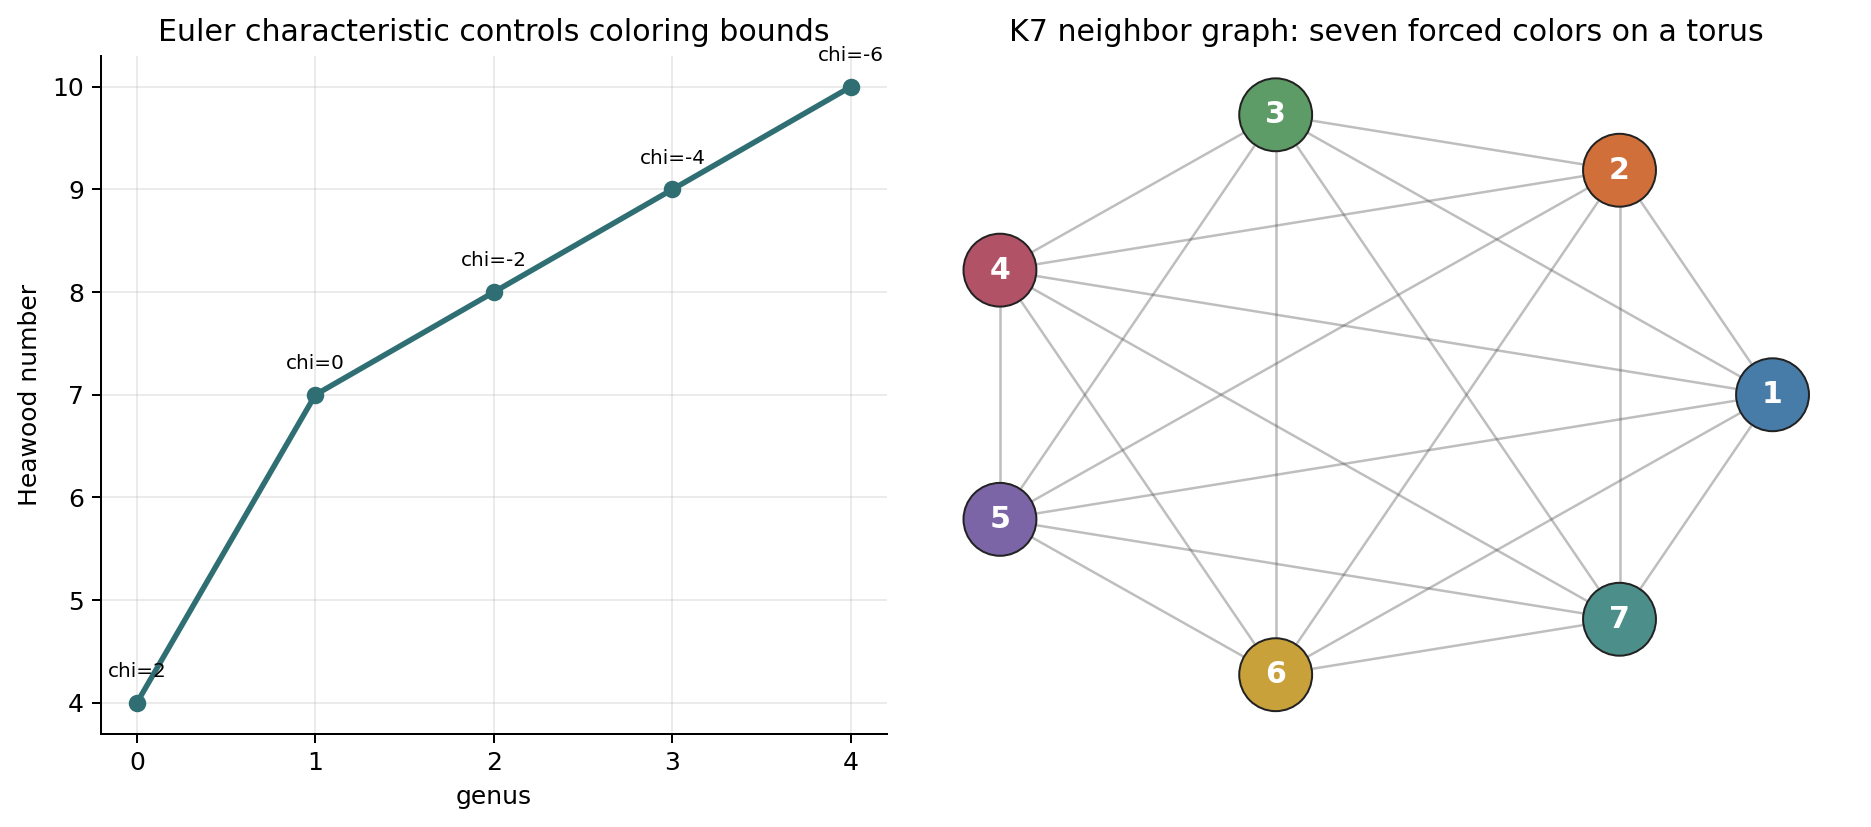

,genus,chi,heawood_number
0,0,2,4
1,1,0,7
2,2,-2,8
3,3,-4,9
4,4,-6,10


In [8]:
def heawood_number(chi):
    return int(math.floor((7 + math.sqrt(49 - 24 * chi)) / 2))

coloring_rows = []
for genus in range(0, 5):
    chi = 2 - 2 * genus
    coloring_rows.append({"genus": genus, "chi": chi, "heawood_number": heawood_number(chi)})
coloring_df = pd.DataFrame(coloring_rows)

K7 = nx.complete_graph(7)
colors = ["#477ca8", "#d16f3b", "#5d9b67", "#b25267", "#7b65a7", "#c8a13a", "#4c8f8a"]
map_coloring_path = FIGURES / "map-coloring-heawood-bound.png"
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.7), gridspec_kw={"width_ratios": [1.05, 1.25]})
axes[0].plot(coloring_df["genus"], coloring_df["heawood_number"], marker="o", color="#2f6f73", linewidth=2.2)
for _, row in coloring_df.iterrows():
    axes[0].text(row["genus"], row["heawood_number"] + 0.25, f"chi={row['chi']}", ha="center", fontsize=8)
axes[0].set_xlabel("genus")
axes[0].set_ylabel("Heawood number")
axes[0].set_title("Euler characteristic controls coloring bounds")
axes[0].set_xticks(coloring_df["genus"])
axes[0].grid(alpha=0.25)
pos = nx.circular_layout(K7)
nx.draw_networkx_edges(K7, pos, ax=axes[1], width=1.0, alpha=0.38, edge_color="#555555")
nx.draw_networkx_nodes(K7, pos, ax=axes[1], node_color=colors, node_size=850, edgecolors="#222222", linewidths=0.8)
nx.draw_networkx_labels(K7, pos, labels={i: str(i + 1) for i in range(7)}, ax=axes[1], font_color="white", font_weight="bold")
axes[1].set_title("K7 neighbor graph: seven forced colors on a torus")
axes[1].axis("off")
fig.tight_layout()
fig.savefig(map_coloring_path, bbox_inches="tight")
plt.close(fig)

map_coloring_check = {"heawood_rows": coloring_rows, "torus_chi": 0, "torus_heawood_number": heawood_number(0), "K7_nodes": int(K7.number_of_nodes()), "K7_edges": int(K7.number_of_edges()), "K7_clique_number": 7}
map_coloring_check_path = save_json(map_coloring_check, UNIT, "checks", "map-coloring-heawood-bound.json", root=ARTIFACT_ROOT)

assert map_coloring_check["torus_heawood_number"] == 7
assert K7.number_of_edges() == 21
assert_artifact(map_coloring_path, min_bytes=1000)
display_artifact(map_coloring_path, width=940)
coloring_df


## Holonomy: Curvature Measured By Parallel Transport

Holonomy turns the local theorem into an experiment: carry a tangent vector around a closed loop and compare the ending direction with the starting direction. For a simple positively oriented loop bounding \(R\), Gauss-Bonnet gives

\[
h_\gamma = \int_R K\,dA.
\]

On the unit sphere, the holonomy around a cap boundary is exactly the area of the cap.


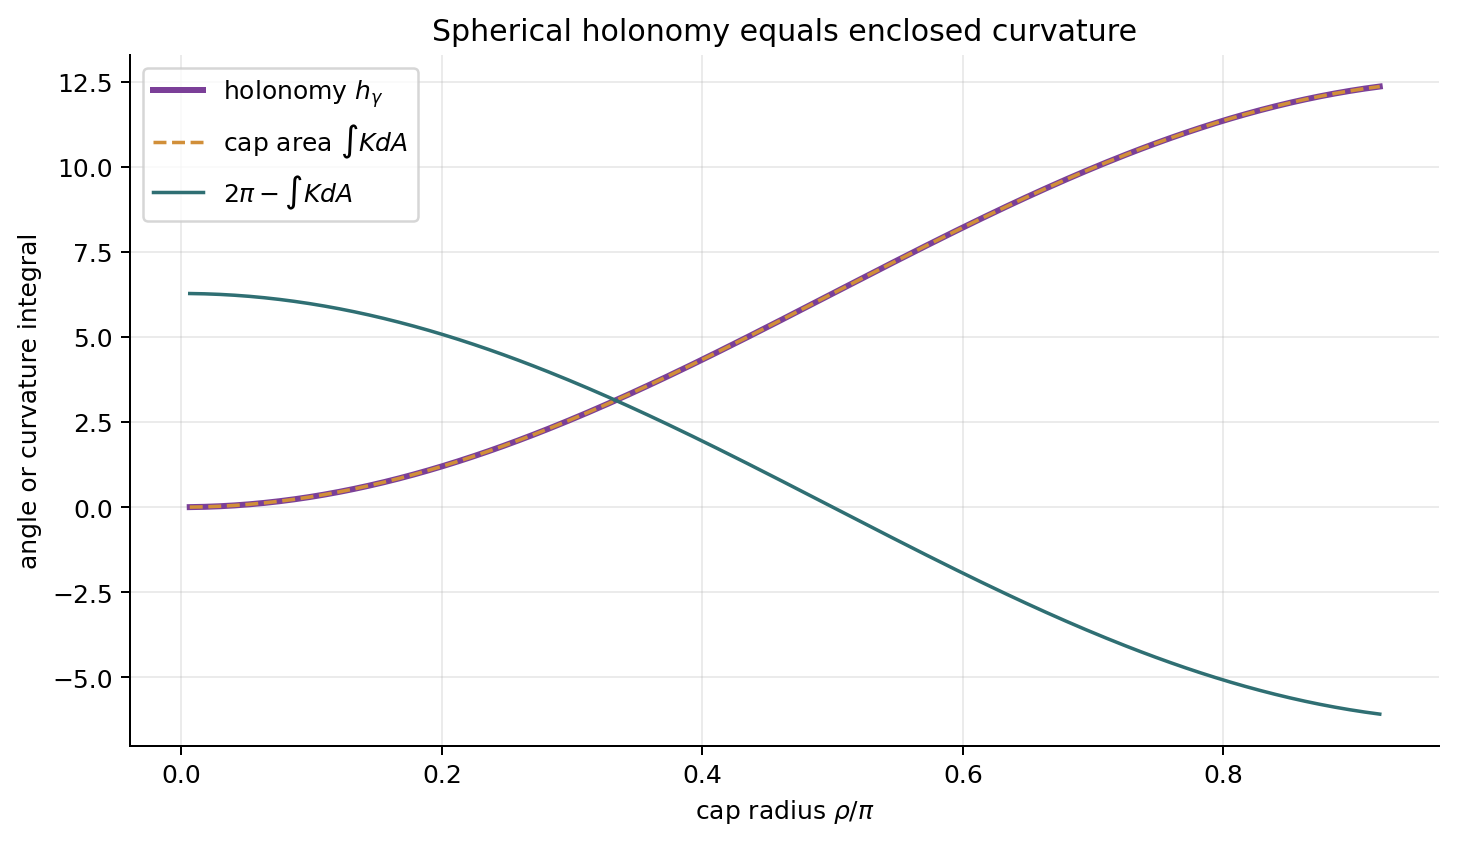

,rho,holonomy,curvature_integral,residual
0,0.314159,0.307521,0.307521,0.0
1,1.036726,3.084784,3.084784,0.0
2,2.073451,9.310133,9.310133,0.0


In [9]:
rho_grid = np.linspace(0.02, 0.92 * math.pi, 240)
cap_area = TAU * (1 - np.cos(rho_grid))
holonomy = cap_area.copy()
boundary_turning = TAU - holonomy

holonomy_path = FIGURES / "holonomy-curvature-area.png"
fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.plot(rho_grid / math.pi, holonomy, color="#7b3f98", linewidth=2.4, label=r"holonomy $h_\gamma$")
ax.plot(rho_grid / math.pi, cap_area, color="#d18f39", linewidth=1.4, linestyle="--", label=r"cap area $\int K dA$")
ax.plot(rho_grid / math.pi, boundary_turning, color="#2f6f73", linewidth=1.4, label=r"$2\pi - \int K dA$")
ax.set_xlabel(r"cap radius $\rho/\pi$")
ax.set_ylabel("angle or curvature integral")
ax.set_title("Spherical holonomy equals enclosed curvature")
ax.legend(loc="best")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(holonomy_path, bbox_inches="tight")
plt.close(fig)

sample_rhos = [0.1 * math.pi, 0.33 * math.pi, 0.66 * math.pi]
holonomy_samples = []
for rho_value in sample_rhos:
    value = TAU * (1 - math.cos(rho_value))
    holonomy_samples.append({"rho": float(rho_value), "holonomy": float(value), "curvature_integral": float(value), "residual": 0.0})
holonomy_check = {"identity": "h_gamma = int_region K dA for simple loops on unit sphere", "samples": holonomy_samples, "max_abs_residual": 0.0}
holonomy_check_path = save_json(holonomy_check, UNIT, "checks", "holonomy-curvature-area.json", root=ARTIFACT_ROOT)

assert holonomy_check["max_abs_residual"] < TOL
assert_artifact(holonomy_path, min_bytes=1000)
display_artifact(holonomy_path, width=900)
pd.DataFrame(holonomy_samples)


## Vector-Field Indices: Local Winding Becomes Global Topology

A stationary point of a tangent vector field is measured by the winding number of the vector direction around a small positively oriented loop. This is the local index. The global theorem says the sum of all such local indices on a compact surface is \(\chi(S)\).

The gallery computes the winding numerically along the unit circle. The source, sink, and vortex each rotate once with the loop. The saddle rotates once in the opposite direction.


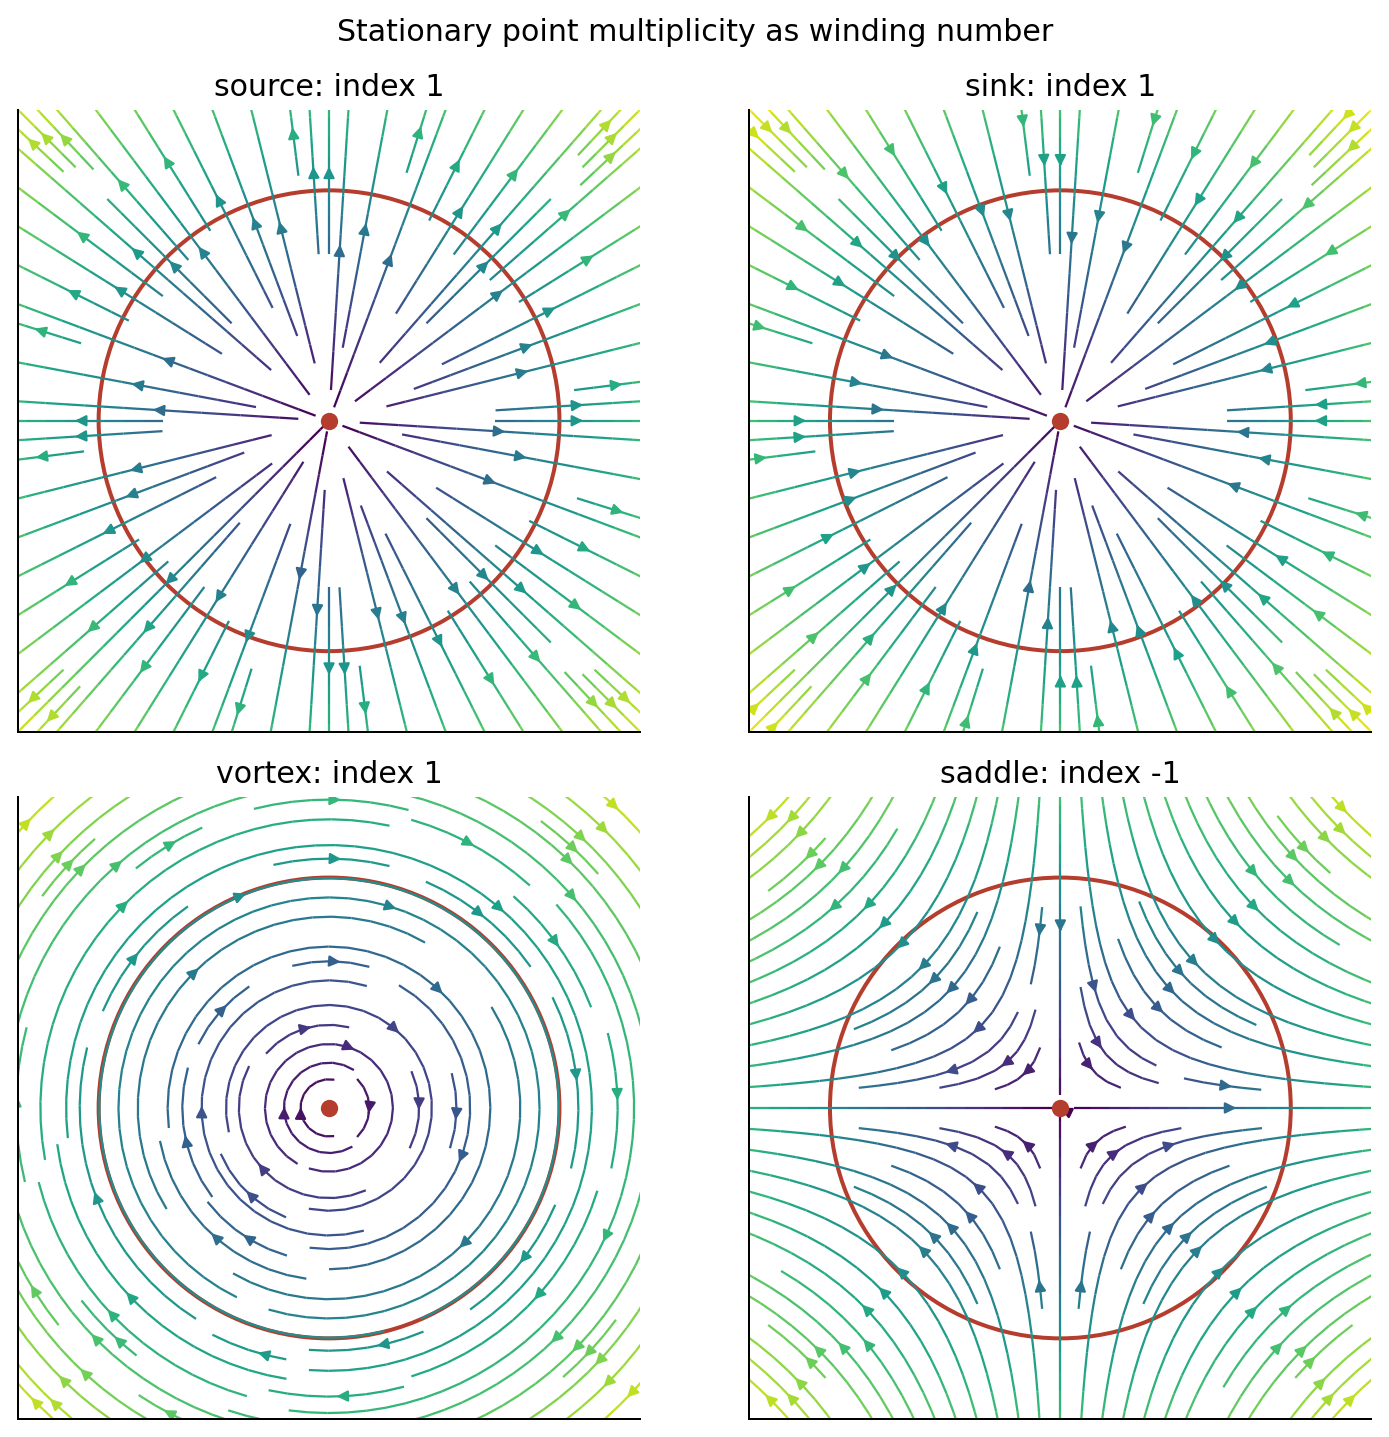

,field,numeric_index,rounded_index
0,source,1.0,1
1,sink,1.0,1
2,vortex,1.0,1
3,saddle,-1.0,-1


In [10]:
def vector_field(name, X, Y):
    if name == "source":
        return X, Y
    if name == "sink":
        return -X, -Y
    if name == "vortex":
        return Y, -X
    if name == "saddle":
        return X, -Y
    raise ValueError(name)

def winding_index(name, samples=2001):
    t = np.linspace(0, TAU, samples)
    x = np.cos(t)
    y = np.sin(t)
    u_vec, v_vec = vector_field(name, x, y)
    angles = np.unwrap(np.arctan2(v_vec, u_vec))
    return float((angles[-1] - angles[0]) / TAU)

names = ["source", "sink", "vortex", "saddle"]
index_rows = []
for name in names:
    value = winding_index(name)
    index_rows.append({"field": name, "numeric_index": value, "rounded_index": int(round(value))})

x_values = np.linspace(-1.4, 1.4, 40)
y_values = np.linspace(-1.4, 1.4, 40)
X_field, Y_field = np.meshgrid(x_values, y_values)
vector_index_path = FIGURES / "vector-field-index-gallery.png"
fig, axes = plt.subplots(2, 2, figsize=(8.4, 8.1))
for ax, row in zip(axes.ravel(), index_rows):
    U_field, V_field = vector_field(row["field"], X_field, Y_field)
    speed = np.hypot(U_field, V_field)
    ax.streamplot(X_field, Y_field, U_field, V_field, color=np.clip(speed, 0, 2), cmap="viridis", density=1.1, linewidth=0.9, arrowsize=0.9)
    circle = plt.Circle((0, 0), 1, fill=False, color="#b53d2d", linewidth=1.6)
    ax.add_patch(circle)
    ax.scatter([0], [0], s=35, color="#b53d2d", zorder=3)
    ax.set_aspect("equal")
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{row['field']}: index {row['rounded_index']}")
fig.suptitle("Stationary point multiplicity as winding number", y=0.98)
fig.tight_layout()
fig.savefig(vector_index_path, bbox_inches="tight")
plt.close(fig)

vector_index_check = {"loop": "unit circle around origin", "fields": index_rows, "expected_indices": {"source": 1, "sink": 1, "vortex": 1, "saddle": -1}}
vector_index_check_path = save_json(vector_index_check, UNIT, "checks", "vector-field-indices.json", root=ARTIFACT_ROOT)

assert [row["rounded_index"] for row in index_rows] == [1, 1, 1, -1]
assert_artifact(vector_index_path, min_bytes=1000)
display_artifact(vector_index_path, width=820)
pd.DataFrame(index_rows)


## Critical Points: Gradient Indices And The Morse Count

The gradient of a smooth function on a surface is a tangent vector field. At a non-degenerate critical point, the Hessian decides the index of that gradient field:

- local maximum: \(+1\),
- saddle: \(-1\),
- local minimum: \(+1\).

For a standard torus and the function \(F(u,v)=(R+r\cos u)\cos v+3\), there are four critical points. The two saddles cancel the maximum and minimum, so the Morse count is \(0\), matching \(\chi(T^2)=0\).


In [11]:
R = 2.0
r = 0.72
u_vals = np.linspace(0, TAU, 100)
v_vals = np.linspace(0, TAU, 72)
U_grid, V_grid = np.meshgrid(u_vals, v_vals, indexing="ij")
X_torus = (R + r * np.cos(U_grid)) * np.cos(V_grid)
Y_torus = (R + r * np.cos(U_grid)) * np.sin(V_grid)
Z_torus = r * np.sin(U_grid)
F_torus = X_torus + 3.0

critical_params = [(0.0, 0.0, "maximum"), (math.pi, 0.0, "saddle"), (0.0, math.pi, "minimum"), (math.pi, math.pi, "saddle")]
critical_rows = []
for uu, vv, label in critical_params:
    point = np.array([(R + r * math.cos(uu)) * math.cos(vv), (R + r * math.cos(uu)) * math.sin(vv), r * math.sin(uu)])
    fuu = -r * math.cos(uu) * math.cos(vv)
    fvv = -(R + r * math.cos(uu)) * math.cos(vv)
    fuv = r * math.sin(uu) * math.sin(vv)
    H = np.array([[fuu, fuv], [fuv, fvv]], dtype=float)
    eig = np.linalg.eigvalsh(H)
    if np.all(eig < 0):
        computed_type = "maximum"
        index = 1
    elif np.all(eig > 0):
        computed_type = "minimum"
        index = 1
    else:
        computed_type = "saddle"
        index = -1
    critical_rows.append({"u": float(uu), "v": float(vv), "x": float(point[0]), "y": float(point[1]), "z": float(point[2]), "declared_type": label, "computed_type": computed_type, "hessian_eigenvalues": [float(eig[0]), float(eig[1])], "gradient_index": index})

fig = go.Figure()
fig.add_surface(x=X_torus, y=Y_torus, z=Z_torus, surfacecolor=F_torus, colorscale="Viridis", opacity=0.92, colorbar=dict(title="F"), name="torus")
for row in critical_rows:
    color = {"maximum": "#b53d2d", "minimum": "#2f6f73", "saddle": "#2f5d9b"}[row["computed_type"]]
    fig.add_trace(go.Scatter3d(x=[row["x"]], y=[row["y"]], z=[row["z"]], mode="markers+text", marker=dict(size=7, color=color), text=[row["computed_type"]], textposition="top center", name=row["computed_type"]))
fig.update_layout(title="Torus critical points for F=x+3: max - saddles + min = chi", scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="z"), margin=dict(l=0, r=0, t=48, b=0), height=620)
torus_critical_html = INTERACTIVE / "torus-critical-points.html"
fig.write_html(torus_critical_html, include_plotlyjs=True, full_html=True)

critical_counts = pd.Series([row["computed_type"] for row in critical_rows]).value_counts().to_dict()
critical_checks = {
    "surface": "standard torus",
    "function": "F=x+3",
    "critical_points": critical_rows,
    "counts": {"maximum": int(critical_counts.get("maximum", 0)), "saddle": int(critical_counts.get("saddle", 0)), "minimum": int(critical_counts.get("minimum", 0))},
    "morse_sum": int(sum(row["gradient_index"] for row in critical_rows)),
    "chi_torus": 0,
}
critical_checks_path = save_json(critical_checks, UNIT, "checks", "critical-point-morse-ledger.json", root=ARTIFACT_ROOT)

assert critical_checks["counts"] == {"maximum": 1, "saddle": 2, "minimum": 1}
assert critical_checks["morse_sum"] == critical_checks["chi_torus"]
assert_artifact(torus_critical_html, min_bytes=1000)
display_artifact(torus_critical_html, width="100%", height=650)
pd.DataFrame(critical_rows)[["u", "v", "computed_type", "hessian_eigenvalues", "gradient_index"]]


,u,v,computed_type,hessian_eigenvalues,gradient_index
0,0.000000,0.000000,maximum,"[-2.7199999999999998, -0.72]",1
1,3.141593,0.000000,saddle,"[-1.28, 0.72]",-1
2,0.000000,3.141593,minimum,"[0.72, 2.7199999999999998]",1
3,3.141593,3.141593,saddle,"[-0.72, 1.28]",-1


## Symbolic Mini-Checks

The notebook uses numerical visuals, but the central identities are exact. These small symbolic checks pin down the formulas used in the plots: the spherical cap budget, the torus curvature integral, the tube limit, and the Heawood quadratic relation.


In [12]:
rho_sym, eps_sym, v_sym, chi_symbol, N_symbol = sp.symbols("rho epsilon v chi N", real=True)
cap_identity = sp.simplify(2 * sp.pi * sp.cos(rho_sym) + 2 * sp.pi * (1 - sp.cos(rho_sym)) - 2 * sp.pi)
torus_integral_exact = sp.integrate(sp.cos(v_sym), (v_sym, 0, 2 * sp.pi)) * sp.integrate(1, (rho_sym, 0, 2 * sp.pi))
tube_limit_exact = sp.limit(sp.Rational(4, 3) * sp.pi * ((1 + eps_sym) ** 3 - (1 - eps_sym) ** 3) / (2 * eps_sym), eps_sym, 0, dir="+")
heawood_root_expr = sp.solve(sp.Eq(N_symbol**2 - 7 * N_symbol + 6 * chi_symbol, 0), N_symbol)[1]

symbolic_checks = {
    "cap_identity_zero": str(cap_identity),
    "torus_total_curvature_exact": str(sp.simplify(torus_integral_exact)),
    "tube_limit_exact": str(tube_limit_exact),
    "heawood_positive_root": str(heawood_root_expr),
}
symbolic_checks_path = save_json(symbolic_checks, UNIT, "checks", "symbolic-identities.json", root=ARTIFACT_ROOT)

assert cap_identity == 0
assert sp.simplify(torus_integral_exact) == 0
assert sp.simplify(tube_limit_exact - 4 * sp.pi) == 0
symbolic_checks


{'cap_identity_zero': '0',
 'torus_total_curvature_exact': '0',
 'tube_limit_exact': '4*pi',
 'heawood_positive_root': 'sqrt(49 - 24*chi)/2 + 7/2'}

## Applied Lab: Curvature, Coloring, And Critical-Point Ledger

Use this lab table as a compact diagnostic. Each row describes the same surface through three independent measurements:

- global curvature: \(\frac{1}{2\pi}\int K\,dA\),
- vector-field index sum,
- Morse count from a height-like function.

When the measurements agree, they identify the same Euler characteristic. The genus column then follows from \(\chi=2-2g\).


In [13]:
lab_rows = [
    {"surface": "sphere", "curvature_integral_over_2pi": 2, "vector_index_sum": 2, "maxima": 1, "saddles": 0, "minima": 1},
    {"surface": "torus", "curvature_integral_over_2pi": 0, "vector_index_sum": 0, "maxima": 1, "saddles": 2, "minima": 1},
    {"surface": "double_torus", "curvature_integral_over_2pi": -2, "vector_index_sum": -2, "maxima": 1, "saddles": 4, "minima": 1},
]
lab_df = pd.DataFrame(lab_rows)
lab_df["morse_sum"] = lab_df["maxima"] - lab_df["saddles"] + lab_df["minima"]
lab_df["chi"] = lab_df["morse_sum"]
lab_df["genus_from_chi"] = (2 - lab_df["chi"]) // 2
lab_df["measurements_agree"] = (lab_df["curvature_integral_over_2pi"] == lab_df["chi"]) & (lab_df["vector_index_sum"] == lab_df["chi"])

lab_table_path = TABLES / "applied-lab-topology-ledger.csv"
lab_df.to_csv(lab_table_path, index=False)
lab_summary = {
    "lab_goal": "infer Euler characteristic from curvature, index, and Morse-count measurements",
    "rows": lab_df.to_dict(orient="records"),
    "all_measurements_agree": bool(lab_df["measurements_agree"].all()),
}
lab_summary_path = save_json(lab_summary, UNIT, "checks", "applied-lab-summary.json", root=ARTIFACT_ROOT)

assert lab_summary["all_measurements_agree"]
assert_artifact(lab_table_path, min_bytes=80)
lab_df


,surface,curvature_integral_over_2pi,vector_index_sum,maxima,saddles,minima,morse_sum,chi,genus_from_chi,measurements_agree
0,sphere,2,2,1,0,1,2,2,0,True
1,torus,0,0,1,2,1,0,0,1,True
2,double_torus,-2,-2,1,4,1,-2,-2,2,True


## Final Sanity Checks

The final cell checks the chapter's core identities and verifies that every generated artifact exists and is nonempty. It also writes a reusable `final-sanity.json` report under the Chapter 13 artifact subtree.


In [14]:
notebook_sanity = {
    "unit": UNIT,
    "notebook_path": "chapter-13-the-gauss-bonnet-theorem/13-the-gauss-bonnet-theorem.ipynb",
    "source_span": source_span,
    "visual_count": len(visual_storyboard),
    "chapter_specific_visuals": [item["item"] for item in visual_storyboard],
    "generic_builder_removed": True,
    "applied_lab_rows": int(len(lab_df)),
}
notebook_sanity_path = save_json(notebook_sanity, UNIT, "checks", "notebook-sanity.json", root=ARTIFACT_ROOT)

artifact_manifest = [
    notebook_sanity_path,
    source_span_path,
    storyboard_path,
    local_budget_path,
    local_budget_check_path,
    triangle_html,
    triangle_check_path,
    compact_integration_path,
    compact_integration_check_path,
    proof_state_path,
    global_gb_ledger_path,
    map_coloring_path,
    map_coloring_check_path,
    holonomy_path,
    holonomy_check_path,
    vector_index_path,
    vector_index_check_path,
    torus_critical_html,
    critical_checks_path,
    symbolic_checks_path,
    lab_table_path,
    lab_summary_path,
]

for artifact in artifact_manifest:
    suffix = Path(artifact).suffix.lower()
    min_bytes = 1000 if suffix in {".png", ".html"} else 32
    assert_artifact(artifact, min_bytes=min_bytes)

identity_checks = {
    "local_budget_max_abs_residual": float(local_budget_check["max_abs_residual"]),
    "spherical_triangle_residual": float(triangle_check["residual"]),
    "compact_tube_relative_error_at_smallest_epsilon": float(compact_integration_check["relative_error_at_smallest_epsilon"]),
    "sphere_global_residual": float(global_curvature_checks["sphere"]["curvature_integral"] - global_curvature_checks["sphere"]["target"]),
    "torus_global_residual": float(global_curvature_checks["torus"]["curvature_integral_midpoint"] - global_curvature_checks["torus"]["target"]),
    "map_coloring_torus_heawood_number": int(map_coloring_check["torus_heawood_number"]),
    "holonomy_max_abs_residual": float(holonomy_check["max_abs_residual"]),
    "vector_indices": [int(row["rounded_index"]) for row in index_rows],
    "critical_point_morse_sum": int(critical_checks["morse_sum"]),
    "critical_point_chi_torus": int(critical_checks["chi_torus"]),
    "applied_lab_measurements_agree": bool(lab_summary["all_measurements_agree"]),
}

assert identity_checks["local_budget_max_abs_residual"] < TOL
assert abs(identity_checks["spherical_triangle_residual"]) < TOL
assert abs(identity_checks["compact_tube_relative_error_at_smallest_epsilon"]) < 1e-6
assert abs(identity_checks["sphere_global_residual"]) < TOL
assert abs(identity_checks["torus_global_residual"]) < 1e-12
assert identity_checks["map_coloring_torus_heawood_number"] == 7
assert identity_checks["vector_indices"] == [1, 1, 1, -1]
assert identity_checks["critical_point_morse_sum"] == identity_checks["critical_point_chi_torus"]
assert identity_checks["applied_lab_measurements_agree"]

final_sanity = {
    "source_span": source_span,
    "artifact_count": len(artifact_manifest),
    "artifacts": [rel(path) for path in artifact_manifest],
    "identity_checks": identity_checks,
    "status": "passed",
}
final_sanity_path = save_json(final_sanity, UNIT, "checks", "final-sanity.json", root=ARTIFACT_ROOT)
assert_artifact(final_sanity_path, min_bytes=512)
final_sanity


{'source_span': {'book': 'Andrew Pressley, Elementary Differential Geometry, Second Edition',
  'chapter': 'Chapter 13: The Gauss-Bonnet theorem',
  'printed_pages': '335-378',
  'pdf_pages': '336-378',
  'sections': ['13.1', '13.2', '13.3', '13.4', '13.5', '13.6', '13.7', '13.8'],
  'source_use': 'orientation only; no textbook prose, figures, hints, solutions, screenshots, or page crops copied'},
 'artifact_count': 22,
 'artifacts': ['artifacts/chapter-13/checks/notebook-sanity.json',
  'artifacts/chapter-13/checks/source-span.json',
  'artifacts/chapter-13/checks/visual-storyboard.json',
  'artifacts/chapter-13/figures/local-gauss-bonnet-budget.png',
  'artifacts/chapter-13/checks/local-gauss-bonnet-budget.json',
  'artifacts/chapter-13/interactive/spherical-triangle-angle-area.html',
  'artifacts/chapter-13/checks/spherical-triangle-angle-area.json',
  'artifacts/chapter-13/figures/compact-integration-tube-limit.png',
  'artifacts/chapter-13/checks/compact-integration-tube-limit.jso

## Takeaways

- Local Gauss-Bonnet is a budget: boundary turning and enclosed curvature compensate each other.
- Corners add explicit angle terms, so geodesic polygons turn area into angle excess or deficit.
- Compact-surface integration can be modeled by a shrinking normal tube; this lets curvature be integrated without one global patch.
- The global theorem is a cancellation argument over a triangulation: only \(V-E+F\) survives.
- Once \(\chi\) is known, it reappears in map coloring, holonomy, vector-field index sums, and Morse critical-point counts.
